<a href="https://colab.research.google.com/github/thapaprabin/Machine_learning/blob/main/support_vector_machines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import pandas as pd
df=pd.read_csv('titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [29]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [30]:
df.shape

(891, 12)

In [31]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [32]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [33]:
df.drop(columns=['Cabin','Ticket','PassengerId'], inplace=True)

In [34]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [35]:
df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,13.0000,S
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,30.0000,S
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,23.4500,S
889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,30.0000,C


In [36]:
df.drop(columns=['Name'], inplace=True)

In [37]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [38]:
df['Embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [39]:
df.isna().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,2


In [40]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df['Age'].fillna(df['Age'].median(), inplace=True)

/tmp/ipykernel_960/4229562025.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
/tmp/ipykernel_960/4229562025.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=T

In [41]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,28.0,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [42]:
df.isna().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [43]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
display(df.head())

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,S
1,1,1,1,38.0,1,0,71.2833,C
2,1,3,1,26.0,0,0,7.9250,S
3,1,1,1,35.0,1,0,53.1000,S
4,0,3,0,35.0,0,0,8.0500,S


In [44]:
df['Embarked'].unique()

array(['S', 'C', 'Q'], dtype=object)

In [ ]:
# Apply One-Hot Encoding to the Embarked column
df = pd.get_dummies(df, columns=['Embarked'], prefix='Emb', dtype=int)

# Display the first few rows to see the new columns
display(df.head())

In [47]:
df = pd.get_dummies(df, columns=['Embarked'], prefix='Embarked', dtype=int)

display(df.head())

KeyError: "None of [Index(['Embarked'], dtype='object')] are in the [columns]"

In [48]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,0,0,1
1,1,1,1,38.0,1,0,71.2833,1,0,0
2,1,3,1,26.0,0,0,7.9250,0,0,1
3,1,1,1,35.0,1,0,53.1000,0,0,1
4,0,3,0,35.0,0,0,8.0500,0,0,1
...,...,...,...,...,...,...,...,...,...,...
886,0,2,0,27.0,0,0,13.0000,0,0,1
887,1,1,1,19.0,0,0,30.0000,0,0,1
888,0,3,1,28.0,1,2,23.4500,0,0,1
889,1,1,0,26.0,0,0,30.0000,1,0,0


In [49]:
from sklearn.preprocessing import StandardScaler

# Define the numeric columns to scale
scaler = StandardScaler()
num_cols = ['Age', 'SibSp', 'Parch', 'Fare']

# Apply the scaler
df[num_cols] = scaler.fit_transform(df[num_cols])

# Display the scaled data
display(df.head())

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,0,3,0,-0.565736,0.432793,-0.473674,-0.502445,0,0,1
1,1,1,1,0.663861,0.432793,-0.473674,0.786845,1,0,0
2,1,3,1,-0.258337,-0.474545,-0.473674,-0.488854,0,0,1
3,1,1,1,0.433312,0.432793,-0.473674,0.420730,0,0,1
4,0,3,0,0.433312,-0.474545,-0.473674,-0.486337,0,0,1


#now the data is cleaned


Training using SVM

In [51]:
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import warnings


In [52]:
cleaned_df = df.copy()
cleaned_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,0,3,0,-0.565736,0.432793,-0.473674,-0.502445,0,0,1
1,1,1,1,0.663861,0.432793,-0.473674,0.786845,1,0,0
2,1,3,1,-0.258337,-0.474545,-0.473674,-0.488854,0,0,1
3,1,1,1,0.433312,0.432793,-0.473674,0.420730,0,0,1
4,0,3,0,0.433312,-0.474545,-0.473674,-0.486337,0,0,1


In [54]:
X=df.drop('Survived',axis=1)
y=df['Survived']
print('Shape of X = ', X.shape)
print('Shape of y = ', y.shape)
print(y.value_counts())

Shape of X =  (891, 9)
Shape of y =  (891,)
Survived
0    549
1    342
Name: count, dtype: int64


In [57]:
X_train,X_test,y_train,y_test=train_test_split(X,y,
                                               test_size=0.2,
                                               random_state=41,
                                               stratify=y)
print('Shape of X_train = ', X_train.shape)
print(f'Shape of y_train = ', {y_train.mean()*100})
print('Shape of X_test = ', X_test.shape)
print(f'Shape of y_test = ', {y_test.mean()*100})


Shape of X_train =  (712, 9)
Shape of y_train =  {np.float64(38.342696629213485)}
Shape of X_test =  (179, 9)
Shape of y_test =  {np.float64(38.547486033519554)}


In [58]:
svm_model=SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    random_state=41,
    probability=True
)
svm_model.fit(X_train,y_train)
print('Model trained sucessfully')

Model trained sucessfully


In [61]:
#make predictions
y_pred=svm_model.predict(X_test)
y_pred_prob=svm_model.predict_proba(X_test)[:,1]
accuracy=accuracy_score(y_test,y_pred)
print("\n📊 Test Accuracy: ", accuracy)


📊 Test Accuracy:  0.8715083798882681


In [63]:
#confusion matrix
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[102   8]
 [ 15  54]]


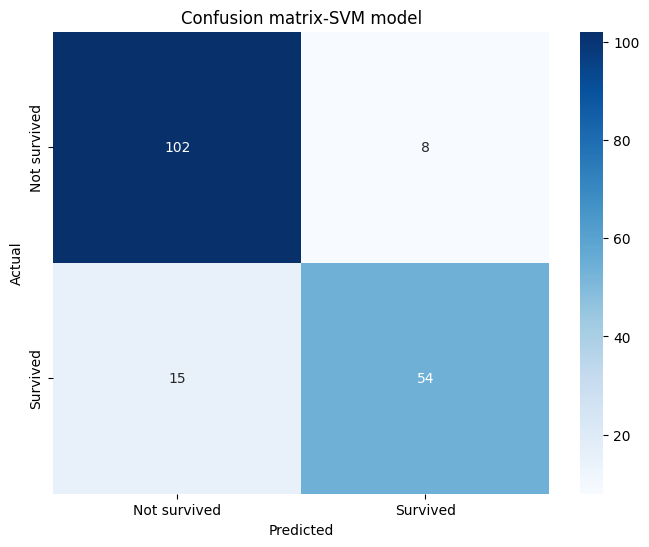

In [65]:
#visualize confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=['Not survived','Survived'],
            yticklabels=['Not survived','Survived'])
plt.title('Confusion matrix-SVM model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()